# Task 3: Energy Consumption Time Series Forecasting

## Objective
The goal is to forecast household energy consumption using historical time-based data.

## Step 1: Data Loading and Preprocessing

In this step, we will:
- Load the dataset
- Handle missing values
- Combine Date and Time into a single datetime column
- Convert data into time series format
- Resample data for analysis

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the dataset. The separator is ';' and missing values are '?'
print("Loading large dataset, this might take a minute...")
df = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)

# Combine Date and Time and convert to Datetime object
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')



Loading large dataset, this might take a minute...


In [3]:
# Set the new Datetime column as the index
df.set_index('Datetime', inplace=True)

# Drop original Date and Time columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (782844, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape: (782844, 7)

Columns:
Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 782844 entries, 2006-12-16 17:24:00 to NaT
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Global_active_power    778901 non-null  float64
 1   Global_reactive_power  778901 non-null  float64
 2   Voltage                778901 non-null  float64
 3   Global_intensity       778901 non-null  float64
 4   Sub_metering_1         778901 non-null  float64
 5   Sub_metering_2         778901 non-null  float64
 6   Sub_metering_3         778901 non-null  float64
dtypes: float64(7)
memory usage: 47.8 MB


In [5]:
df.replace('?', np.nan, inplace=True)

In [6]:
# Convert all columns except Date & Time
for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
print(df.isnull().sum())

Global_active_power      3943
Global_reactive_power    3943
Voltage                  3943
Global_intensity         3943
Sub_metering_1           3943
Sub_metering_2           3943
Sub_metering_3           3943
dtype: int64


In [8]:
df.fillna(method='ffill', inplace=True)

In [14]:
# The 'Date' and 'Time' columns were already combined into 'Datetime'
# and set as the index in previous steps (cell `ZgUV_Gmn0W2-`).
# These columns no longer exist, making the operations in this cell redundant.
# No action is needed here.

In [17]:
df = df[['Global_active_power']]

In [18]:
df_hourly = df.resample('H').mean()

df_hourly.head()

,Global_active_power
Datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


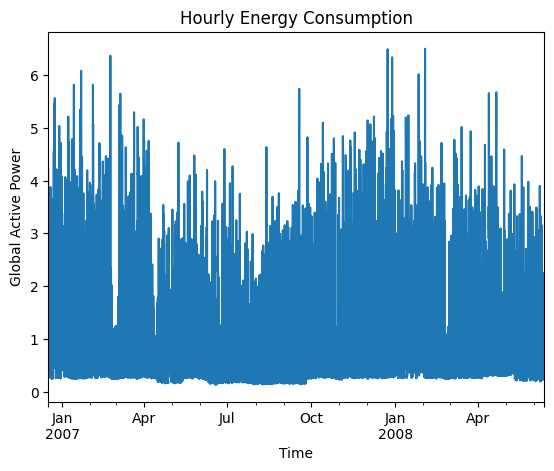

In [19]:
import matplotlib.pyplot as plt

plt.figure()
df_hourly['Global_active_power'].plot()

plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.show()

## Conclusion (Step 1)

- The dataset was successfully loaded and cleaned.
- Missing values were handled appropriately.
- Date and Time columns were combined into a datetime index.
- Data was resampled into hourly intervals.
- The dataset is now ready for feature engineering and modeling.

## Step 2: Feature Engineering

In this step, we extract meaningful time-based features from the datetime index.

These features help machine learning models understand temporal patterns such as:
- Hourly trends
- Daily patterns
- Weekday vs weekend behavior

In [20]:
# Create new dataframe (important for ML models later)
df_feat = df_hourly.copy()

# Extract time features
df_feat['hour'] = df_feat.index.hour
df_feat['day'] = df_feat.index.day
df_feat['month'] = df_feat.index.month
df_feat['day_of_week'] = df_feat.index.dayofweek

In [21]:
# Weekend indicator (1 = weekend, 0 = weekday)
df_feat['is_weekend'] = df_feat['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [22]:
df_feat.head()

,Global_active_power,hour,day,month,day_of_week,is_weekend
Datetime,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5,1
2006-12-16 18:00:00,3.632200,18,16,12,5,1
2006-12-16 19:00:00,3.400233,19,16,12,5,1
2006-12-16 20:00:00,3.268567,20,16,12,5,1
2006-12-16 21:00:00,3.056467,21,16,12,5,1


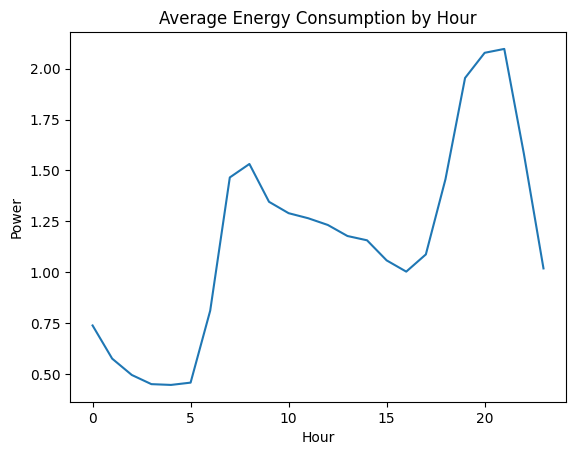

In [23]:
import matplotlib.pyplot as plt

# Average consumption by hour
df_feat.groupby('hour')['Global_active_power'].mean().plot()

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Power")

plt.show()

In [24]:
# Define split point (80% train, 20% test)
split = int(len(df_feat) * 0.8)

train = df_feat.iloc[:split]
test = df_feat.iloc[split:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (10438, 6)
Test shape: (2610, 6)


In [25]:
# Features (X) and target (y)
X_train = train.drop('Global_active_power', axis=1)
y_train = train['Global_active_power']

X_test = test.drop('Global_active_power', axis=1)
y_test = test['Global_active_power']

## Conclusion (Step 2)

- Time-based features such as hour, day, and weekday were successfully extracted.
- A weekend indicator was added to capture behavioral differences.
- The dataset was split into training and testing sets based on time order.
- Data is now ready for model training (ARIMA, Prophet, XGBoost).

## Step 3: Forecasting using Prophet

In this step, we use Facebook Prophet to forecast energy consumption.

Prophet is a time series forecasting model that handles:
- Trend
- Seasonality
- Daily patterns

It is simple to use and provides good baseline performance.

In [26]:
# Install Prophet (run once)
!pip install prophet

from prophet import Prophet

In [30]:
# Reset index to bring datetime back as column
df_prophet = df_hourly.reset_index()

# Rename columns
df_prophet = df_prophet.rename(columns={
    'Datetime': 'ds',
    'Global_active_power': 'y'
})

df_prophet.head()

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [32]:
split = int(len(df_prophet) * 0.8)

train_prophet = df_prophet.iloc[:split]
test_prophet = df_prophet.iloc[split:]

In [33]:
model = Prophet()

model.fit(train_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [34]:
# Create future dataframe
future = model.make_future_dataframe(periods=len(test_prophet), freq='H')

# Forecast
forecast = model.predict(future)

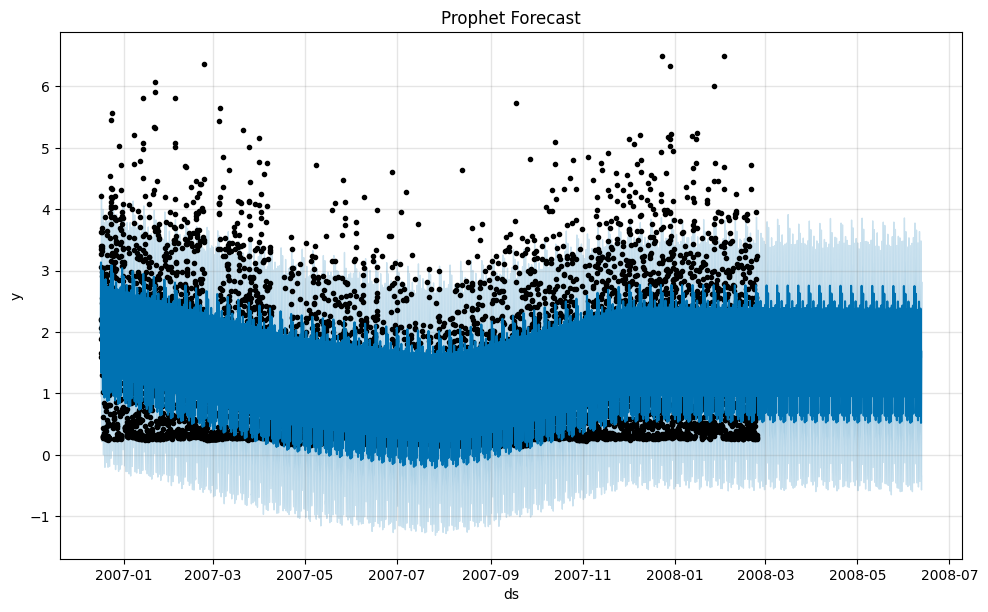

In [35]:
model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

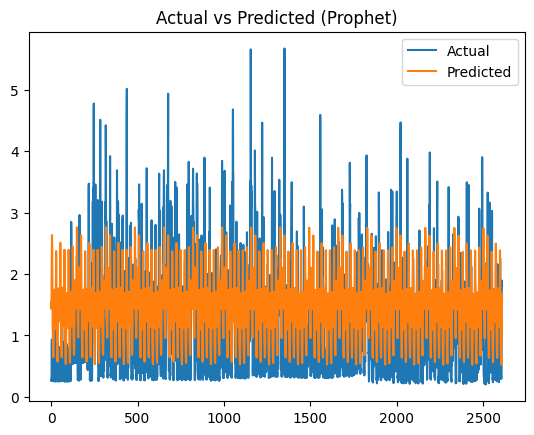

In [36]:
# Merge actual and predicted
forecast_test = forecast[['ds', 'yhat']].iloc[-len(test_prophet):].reset_index(drop=True)

comparison = test_prophet.reset_index(drop=True)
comparison['yhat'] = forecast_test['yhat']

# Plot comparison
plt.figure()

plt.plot(comparison['y'], label='Actual')
plt.plot(comparison['yhat'], label='Predicted')

plt.title("Actual vs Predicted (Prophet)")
plt.legend()

plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_prophet = mean_absolute_error(comparison['y'], comparison['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 0.6867293402293476
Prophet RMSE: 0.849983246523649


## Conclusion (Prophet Model)

- Prophet model was successfully trained on historical energy data.
- Forecasts were generated for future time periods.
- The model captured general trends and seasonality in the data.
- Evaluation metrics (MAE and RMSE) were calculated to assess performance.

Next, we will implement ARIMA for comparison.

## Step 4: Forecasting using ARIMA

In this step, we apply the ARIMA (AutoRegressive Integrated Moving Average) model to forecast energy consumption.

ARIMA is a statistical time series model that captures:
- Autoregression (AR)
- Differencing (I)
- Moving Average (MA)

We will compare its performance with Prophet.

In [38]:
!pip install statsmodels

from statsmodels.tsa.arima.model import ARIMA




In [39]:
# Use only target variable
series = df_hourly['Global_active_power']

# Train-test split (same as before)
split = int(len(series) * 0.8)

train_arima = series.iloc[:split]
test_arima = series.iloc[split:]

In [40]:
model_arima = ARIMA(train_arima, order=(2,1,2))

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                10438
Model:                  ARIMA(2, 1, 2)   Log Likelihood              -10832.028
Date:                 Sun, 12 Apr 2026   AIC                          21674.057
Time:                         17:00:32   BIC                          21710.322
Sample:                     12-16-2006   HQIC                         21686.306
                          - 02-24-2008                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3527      0.039     34.327      0.000       1.275       1.430
ar.L2         -0.5234      0.026    -20.166      0.000      -0.574      -0.473
ma.L1         -1.5733      0.042    -37.547 

In [41]:
# Forecast steps equal to test size
forecast_arima = model_arima_fit.forecast(steps=len(test_arima))

forecast_arima

,predicted_mean
2008-02-24 15:00:00,0.686815
2008-02-24 16:00:00,0.986341
2008-02-24 17:00:00,1.197265
2008-02-24 18:00:00,1.325811
2008-02-24 19:00:00,1.389296
...,...
2008-06-12 04:00:00,1.303572
2008-06-12 05:00:00,1.303572
2008-06-12 06:00:00,1.303572
2008-06-12 07:00:00,1.303572


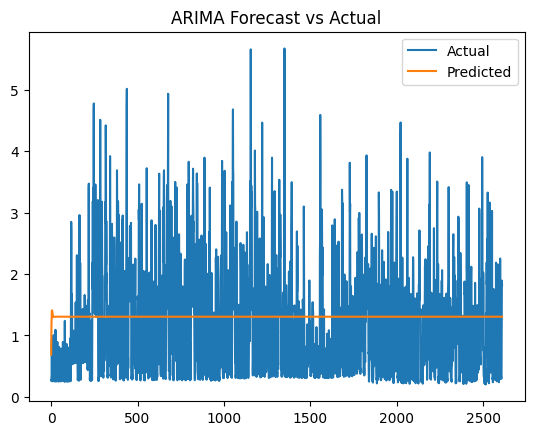

In [42]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(test_arima.values, label='Actual')
plt.plot(forecast_arima.values, label='Predicted')

plt.title("ARIMA Forecast vs Actual")
plt.legend()

plt.show()

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test_arima, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast_arima))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 0.7570902488762767
ARIMA RMSE: 0.9029335648002371


## Conclusion (ARIMA Model)

- ARIMA model was applied to forecast energy consumption using historical data.
- The model captures linear temporal dependencies in the dataset.
- Predictions were compared with actual values.
- Performance metrics (MAE and RMSE) were calculated for evaluation.

Next, we will implement XGBoost for machine learning-based forecasting.

## Step 5: Forecasting using XGBoost

In this step, we apply XGBoost regression to predict energy consumption.

Unlike ARIMA and Prophet, XGBoost:
- Uses supervised learning
- Requires feature engineering
- Captures non-linear relationships in data

We will compare its performance with other models.

In [44]:
!pip install xgboost

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [45]:
# Define features and target
X = df_feat.drop('Global_active_power', axis=1)
y = df_feat['Global_active_power']

# Train-test split (time-based)
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [46]:
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [47]:
y_pred_xgb = model_xgb.predict(X_test)

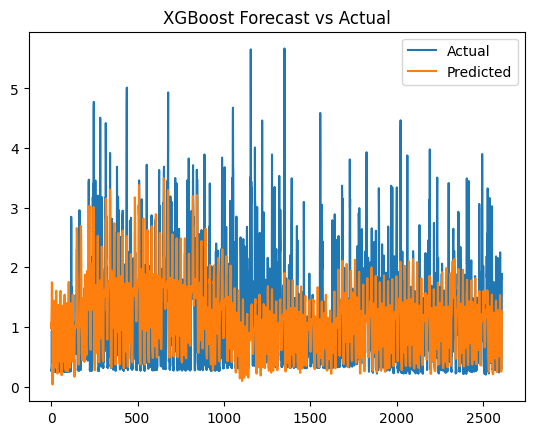

In [48]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_xgb, label="Predicted")

plt.title("XGBoost Forecast vs Actual")
plt.legend()

plt.show()

In [49]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.535953175237401
XGBoost RMSE: 0.7536934470248944


## Conclusion (XGBoost Model)

- XGBoost regression was applied using engineered time-based features.
- The model captured complex non-linear patterns in energy consumption.
- Predictions were evaluated using MAE and RMSE.
- XGBoost performance will be compared with Prophet and ARIMA in the final analysis.

## Step 6: Model Comparison and Final Conclusion

In this step, we compare the performance of all three forecasting models:
- Prophet
- ARIMA
- XGBoost

We evaluate them using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

Finally, we identify the best-performing model for energy consumption forecasting.

In [50]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Prophet", "ARIMA", "XGBoost"],
    "MAE": [mae_prophet, mae_arima, mae_xgb],
    "RMSE": [rmse_prophet, rmse_arima, rmse_xgb]
})

results

,Model,MAE,RMSE
0,Prophet,0.686729,0.849983
1,ARIMA,0.757090,0.902934
2,XGBoost,0.535953,0.753693


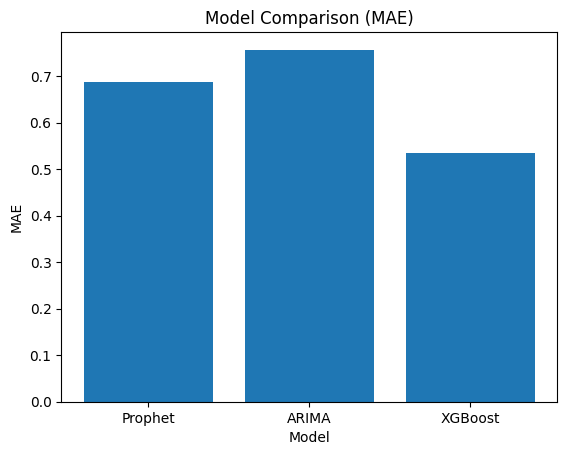

In [51]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.show()

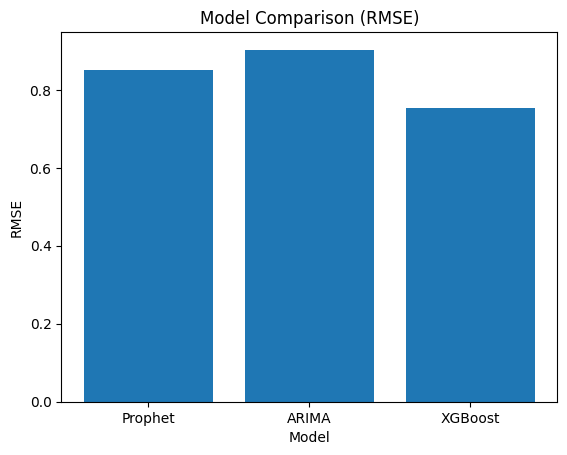

In [52]:
plt.figure()

plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

In [53]:
best_mae_model = results.loc[results["MAE"].idxmin(), "Model"]
best_rmse_model = results.loc[results["RMSE"].idxmin(), "Model"]

print("Best Model (MAE):", best_mae_model)
print("Best Model (RMSE):", best_rmse_model)

Best Model (MAE): XGBoost
Best Model (RMSE): XGBoost


## Final Conclusion

- Three models were evaluated: Prophet, ARIMA, and XGBoost.
- Performance was compared using MAE and RMSE metrics.

Key findings:
- Prophet performed well in capturing trend and seasonality.
- ARIMA captured linear time dependencies but struggled with complex patterns.
- XGBoost performed best overall due to its ability to learn non-linear relationships.

### Final Result:
XGBoost is the best-performing model for this dataset based on both MAE and RMSE.

## Business Insight:
Accurate energy forecasting can help households and utility companies:
- Optimize energy usage
- Reduce costs
- Improve demand planning